# Simple Cat vs Dog CNN Notebook

This notebook is fully self-contained for teaching.

We will do everything here:
- import libraries
- set basic settings
- download CIFAR-10
- keep only cats and dogs
- create train, validation, and test datasets
- build a simple CNN
- train the model
- test the model
- try prediction on another image


## 1. Imports and settings


In [4]:
from pathlib import Path
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from PIL import Image
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import datasets, transforms

DATA_DIR = Path("../data/raw")
BATCH_SIZE = 64
EPOCHS = 3
LEARNING_RATE = 0.001
IMAGE_SIZE = 64
RANDOM_SEED = 42
CLASS_NAMES = ["cat", "dog"]
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

DATA_DIR.mkdir(parents=True, exist_ok=True)

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)

print("Device:", DEVICE)


Device: cpu


## 2. Download CIFAR-10 and keep only cat and dog

CIFAR-10 has 10 classes, but here we only keep:
- cat = 0
- dog = 1


In [5]:
CAT_CLASS_INDEX = 3
DOG_CLASS_INDEX = 5

def filter_cat_dog(cifar_dataset):
    images = []
    labels = []

    for image_array, label in zip(cifar_dataset.data, cifar_dataset.targets):
        if label == CAT_CLASS_INDEX:
            images.append(Image.fromarray(image_array))
            labels.append(0)
        elif label == DOG_CLASS_INDEX:
            images.append(Image.fromarray(image_array))
            labels.append(1)

    return images, labels

train_cifar = datasets.CIFAR10(root=str(DATA_DIR), train=True, download=True)
test_cifar = datasets.CIFAR10(root=str(DATA_DIR), train=False, download=True)

train_images, train_labels = filter_cat_dog(train_cifar)
test_images, test_labels = filter_cat_dog(test_cifar)

print("Filtered train images:", len(train_images))
print("Filtered test images:", len(test_images))


C:\Users\davro\AppData\Roaming\Python\Python314\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Filtered train images: 10000
Filtered test images: 2000


## 3. Create a simple custom dataset

We use a custom dataset because we changed the original CIFAR-10 labels into a binary cat-vs-dog problem.


In [6]:
class CatDogDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):
        image = self.images[index]
        label = self.labels[index]

        if self.transform is not None:
            image = self.transform(image)

        return image, label


## 4. Prepare transforms and dataloaders

For this baseline, we only use resize, tensor conversion, and normalization.


In [7]:
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
])

full_train_dataset = CatDogDataset(train_images, train_labels, transform=transform)
test_dataset = CatDogDataset(test_images, test_labels, transform=transform)

train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
generator = torch.Generator().manual_seed(RANDOM_SEED)
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size], generator=generator)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))


Train samples: 8000
Validation samples: 2000
Test samples: 2000


## 5. Show a few training images


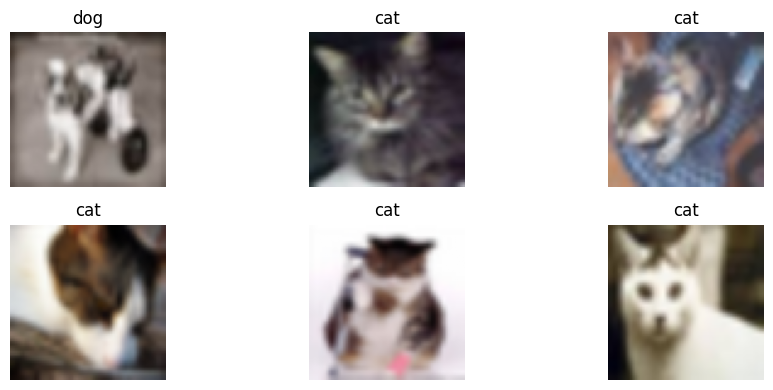

In [8]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(10, 4))
for i in range(6):
    image = images[i].permute(1, 2, 0).numpy()
    image = (image * 0.5) + 0.5
    image = image.clip(0, 1)

    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title(CLASS_NAMES[labels[i].item()])
    plt.axis("off")

plt.tight_layout()
plt.show()


## 6. Build a simple CNN

This is a small beginner-friendly CNN baseline.


In [9]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 64),
            nn.ReLU(),
            nn.Linear(64, 2),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = SimpleCNN().to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(model)


SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=2, bias=True)
  )
)


## 7. Train the model


In [10]:
def run_one_epoch(model, dataloader, criterion, optimizer=None):
    is_training = optimizer is not None
    model.train() if is_training else model.eval()

    running_loss = 0.0
    running_correct = 0
    total_samples = 0

    with torch.set_grad_enabled(is_training):
        for images, labels in dataloader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            if is_training:
                optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            if is_training:
                loss.backward()
                optimizer.step()

            predictions = torch.argmax(outputs, dim=1)
            batch_size = labels.size(0)
            running_loss += loss.item() * batch_size
            running_correct += (predictions == labels).sum().item()
            total_samples += batch_size

    return running_loss / total_samples, 100 * running_correct / total_samples

for epoch in range(EPOCHS):
    train_loss, train_acc = run_one_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = run_one_epoch(model, val_loader, criterion)

    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%"
    )


Epoch 1/3 | Train Loss: 0.6585 | Train Acc: 59.83% | Val Loss: 0.6359 | Val Acc: 64.30%
Epoch 2/3 | Train Loss: 0.6042 | Train Acc: 66.96% | Val Loss: 0.5999 | Val Acc: 67.30%
Epoch 3/3 | Train Loss: 0.5682 | Train Acc: 70.60% | Val Loss: 0.5442 | Val Acc: 72.05%


## 8. Test the model


In [11]:
test_loss, test_acc = run_one_epoch(model, test_loader, criterion)
print("Test Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_acc, 2), "%")


Test Loss: 0.5578
Test Accuracy: 71.55 %


## 9. Predict a few test images


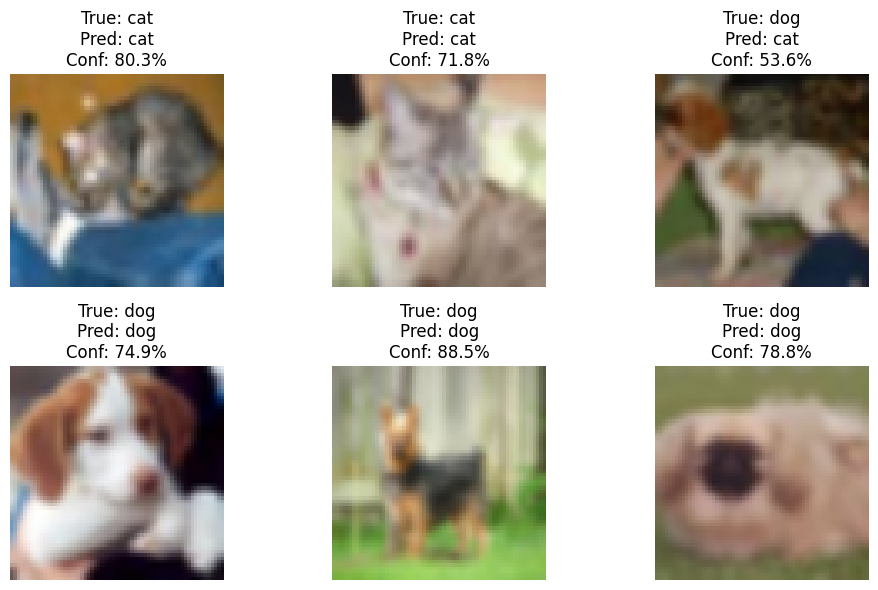

In [12]:
images, labels = next(iter(test_loader))
images_device = images.to(DEVICE)

with torch.no_grad():
    outputs = model(images_device)
    probabilities = torch.softmax(outputs, dim=1)
    confidences, predictions = torch.max(probabilities, dim=1)

predictions = predictions.cpu()
confidences = confidences.cpu()

plt.figure(figsize=(10, 6))
for i in range(6):
    image = images[i].permute(1, 2, 0).numpy()
    image = (image * 0.5) + 0.5
    image = image.clip(0, 1)

    title_text = (
        f"True: {CLASS_NAMES[labels[i].item()]}\n"
        f"Pred: {CLASS_NAMES[predictions[i].item()]}\n"
        f"Conf: {confidences[i].item() * 100:.1f}%"
    )

    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title(title_text)
    plt.axis("off")

plt.tight_layout()
plt.show()


## 10. Try another image

If you place `book.jpeg` in the `notebooks/` folder, the model will try to predict it.


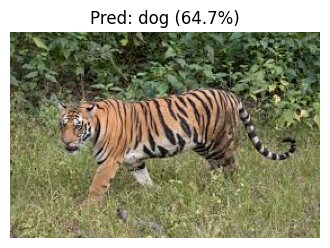

In [18]:
image_name = "tiger.jpeg"   
image_path = Path(image_name)

if image_path.exists():
    image = Image.open(image_path).convert("RGB")
    display_image = image.copy()

    image_tensor = transform(image).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        output = model(image_tensor)
        probabilities = torch.softmax(output, dim=1)
        confidence, prediction = torch.max(probabilities, dim=1)

    predicted_label = CLASS_NAMES[prediction.item()]
    confidence_score = confidence.item() * 100

    plt.figure(figsize=(4, 4))
    plt.imshow(display_image)
    plt.title(f"Pred: {predicted_label} ({confidence_score:.1f}%)")
    plt.axis("off")
    plt.show()
else:
    print(f"{image_path} not found.")
